<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_4_normalizing_flows_density_estimation_direct_likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4 — Direct density estimation with normalizing flows

In the previous exercises we estimated density ratios directly with classifiers.  Here we do a complementary exercise: train two normalizing flows,

$$
\hat p_\mathrm{sig}(x), \qquad \hat p_\mathrm{bkg}(x),
$$

where $x=(x_1,\ldots,x_5)$ are the reconstructed/smeared features.  We then:

1. choose either an affine-coupling RealNVP or a rational-quadratic-spline flow, and train one flow for the background and one for the signal;
2. validate the learned densities using MC feature projections, the distribution of the learned log density, and, for this toy problem, the analytic smeared Gaussian-mixture truth;
3. build the likelihood **directly from the densities**, without forming density ratios and without constructing a workspace;
4. fit the signal-strength parameter $\mu$ with a small JAX likelihood;
5. use the explicit toy density to generate pseudo-experiments and visualize the distribution of the likelihood-ratio test statistic.

The main pedagogical contrast is:

- classifier method: learn $p_i(x)/p_\mathrm{ref}(x)$ directly;
- flow method: learn $p_i(x)$ directly and insert those densities in the likelihood.


In [1]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 2_000_000, 2_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = True                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep nflows

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/98

## Inputs expected by this notebook

This notebook expects the updated generator output:

```text
dataframes/background.parquet
dataframes/signal.parquet
```

with both truth-level columns `z1,...,z5` and reco-level columns `x1,...,x5`.  The fit below uses only the reco-level `x*` variables.

In [2]:
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.special import logsumexp
from scipy.stats import multivariate_normal

import torch

import nsbi_common_utils

from utils import (
    FEATURES,
    background_components,
    signal_components,
    smearing_parameters,
    split_train_inference,
)
from utils_nf import flow_log_prob_x, flow_sample_x, train_flow

FEATURES = list(FEATURES)
N_DIM = len(FEATURES)

SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


Using device: cuda
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


In [3]:
BASE_PATH = Path("./dataframes")
FLOW_MODEL_DIR = Path("models_flows")
DENSITY_DIR = Path("saved_densities_flows")
PLOT_DIR = Path("plots_flows")

for directory in [FLOW_MODEL_DIR, DENSITY_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Must match the density-ratio training/fitting notebooks if you want disjoint
# train/inference samples across all approaches.
SPLIT_SEED = 0
TRAIN_FRACTION = 0.5

# Select the discrete normalizing-flow architecture.
# False: affine-coupling RealNVP; True: rational-quadratic-spline couplings.
USE_QUADRATIC_SPLINE = False
FLOW_TYPE = "quadratic_spline" if USE_QUADRATIC_SPLINE else "realnvp"

# Keep these modest for a tutorial. Increase N_EPOCHS and MAX_TRAIN_EVENTS
# for tighter closure against the analytic truth.
MAX_TRAIN_EVENTS = {
    "background": 1_000_000,
    "signal": 1_000_000,
}

# Model architecture: these choices stay visible and editable for students.
N_COUPLING_LAYERS = 8
HIDDEN_FEATURES = 1024
HIDDEN_LAYERS = 4
SCALE_CLIP = 1.5                 # RealNVP only
SPLINE_NUM_BINS = 8              # quadratic-spline flow only
SPLINE_TAIL_BOUND = 3.0          # in standardized coordinates; spline only
DROPOUT_PROBABILITY = 0.0        # spline conditioner only

# Optimizer and training choices.
BATCH_SIZE = 2048
N_EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
VALIDATION_FRACTION = 0.20
PATIENCE = 5
GRADIENT_CLIP = 5.0

# If checkpoints already exist, load the selected architecture instead of
# retraining. RealNVP and spline checkpoints have distinct filenames.
LOAD_IF_AVAILABLE = True

MODEL_CONFIG = {
    "flow_type": FLOW_TYPE,
    "n_features": N_DIM,
    "n_coupling_layers": N_COUPLING_LAYERS,
    "hidden_features": HIDDEN_FEATURES,
    "hidden_layers": HIDDEN_LAYERS,
    "scale_clip": SCALE_CLIP,
    "spline_num_bins": SPLINE_NUM_BINS,
    "spline_tail_bound": SPLINE_TAIL_BOUND,
    "dropout_probability": DROPOUT_PROBABILITY,
}

TRAINING_CONFIG = {
    "batch_size": BATCH_SIZE,
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "validation_fraction": VALIDATION_FRACTION,
    "patience": PATIENCE,
    "gradient_clip": GRADIENT_CLIP,
}

print(f"Selected flow architecture: {FLOW_TYPE}")


Selected flow architecture: realnvp


## Load data and make the same train/inference split

The flows are trained on the training half.  The likelihood fit is evaluated on the inference half.  This mirrors the density-ratio notebooks and avoids using the same events to learn and evaluate the likelihood.

In [4]:
signal = pd.read_parquet(BASE_PATH / "signal.parquet")
background = pd.read_parquet(BASE_PATH / "background.parquet")

missing = [f for f in FEATURES if f not in signal.columns or f not in background.columns]
if missing:
    raise RuntimeError(
        "Missing reco-level columns "
        f"{missing}. Regenerate the parquet files with the updated generator "
        "that writes x1,...,x5."
    )

for name, df in [("signal", signal), ("background", background)]:
    if "weight" not in df.columns:
        raise RuntimeError(f"{name} dataframe is missing a 'weight' column.")
    print(
        f"{name:10s}: {len(df):,} events, "
        f"sum weights = {df['weight'].sum():.6g}"
    )

signal    : 2,000,000 events, sum weights = 1100
background: 2,000,000 events, sum weights = 1e+06


In [5]:
signal_train, signal_eval = split_train_inference(
    signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED
)
background_train, background_eval = split_train_inference(
    background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED
)

TOTAL_YIELD = {
    "signal": float(signal_train["weight"].sum()),
    "background": float(background_train["weight"].sum()),
}

print(f"Flow training: {len(signal_train):,} signal + {len(background_train):,} background events")
print(f"Fit/eval:      {len(signal_eval):,} signal + {len(background_eval):,} background events")
print(TOTAL_YIELD)

Flow training: 1,000,000 signal + 1,000,000 background events
Fit/eval:      1,000,000 signal + 1,000,000 background events
{'signal': 1099.9999999999925, 'background': 1000000.0}


## Choose and train a normalizing flow

The implementation is kept in `utils_nf.py` so that this workshop notebook can focus on the statistical ideas. The boolean `USE_QUADRATIC_SPLINE` above selects one of two **discrete normalizing flows**:

- **RealNVP:** affine coupling transforms with alternating binary masks;
- **quadratic spline:** piecewise rational-quadratic coupling transforms, which can represent more flexible monotonic maps within each coupling layer.

Both are trained by maximizing the exact log likelihood

$$
\log \hat p(x) = \log p_Z\big(f(x)\big)
+ \log\left|\det\frac{\partial f}{\partial x}\right|.
$$

For numerical stability, each sample is standardized before training. The utility functions include the standardization Jacobian when evaluating a density, so `flow_log_prob_x` always returns $\log \hat p(x)$ in the original `x` coordinates.


### Train the signal and background flows

The architecture and optimizer settings are passed explicitly from the notebook to `train_flow`. Checkpoints are saved under `models_flows/`; RealNVP and spline models use different filenames, so students can train and compare both choices safely.


In [6]:
flows = {}
for sample_name, sample_train, flow_seed in [
    ("background", background_train, 101),
    ("signal", signal_train, 202),
]:
    flows[sample_name] = train_flow(
        sample_name,
        sample_train,
        features=FEATURES,
        model_dir=FLOW_MODEL_DIR,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
        device=device,
        max_train_events=MAX_TRAIN_EVENTS[sample_name],
        load_if_available=LOAD_IF_AVAILABLE,
        seed=flow_seed,
    )


Loading existing background flow from models_flows/realnvp_background.pt
Loading existing signal flow from models_flows/realnvp_signal.pt


## Validation 1: feature and correlation closure

A flow must reproduce not only every one-dimensional feature distribution, but also the dependence among features. The pair plot below summarizes both:

- **diagonal:** overlaid one-dimensional densities for held-out MC and flow-generated events;
- **lower triangle:** shared-range two-dimensional density contours enclosing approximately 68% and 95% of each sample;
- **upper triangle:** the Pearson correlations $\rho_\mathrm{MC}$ and $\rho_\mathrm{flow}$, together with $\Delta\rho = \rho_\mathrm{flow}-\rho_\mathrm{MC}$.

The contours are particularly important: matching all diagonal projections does not guarantee that the flow has learned the joint five-dimensional structure.


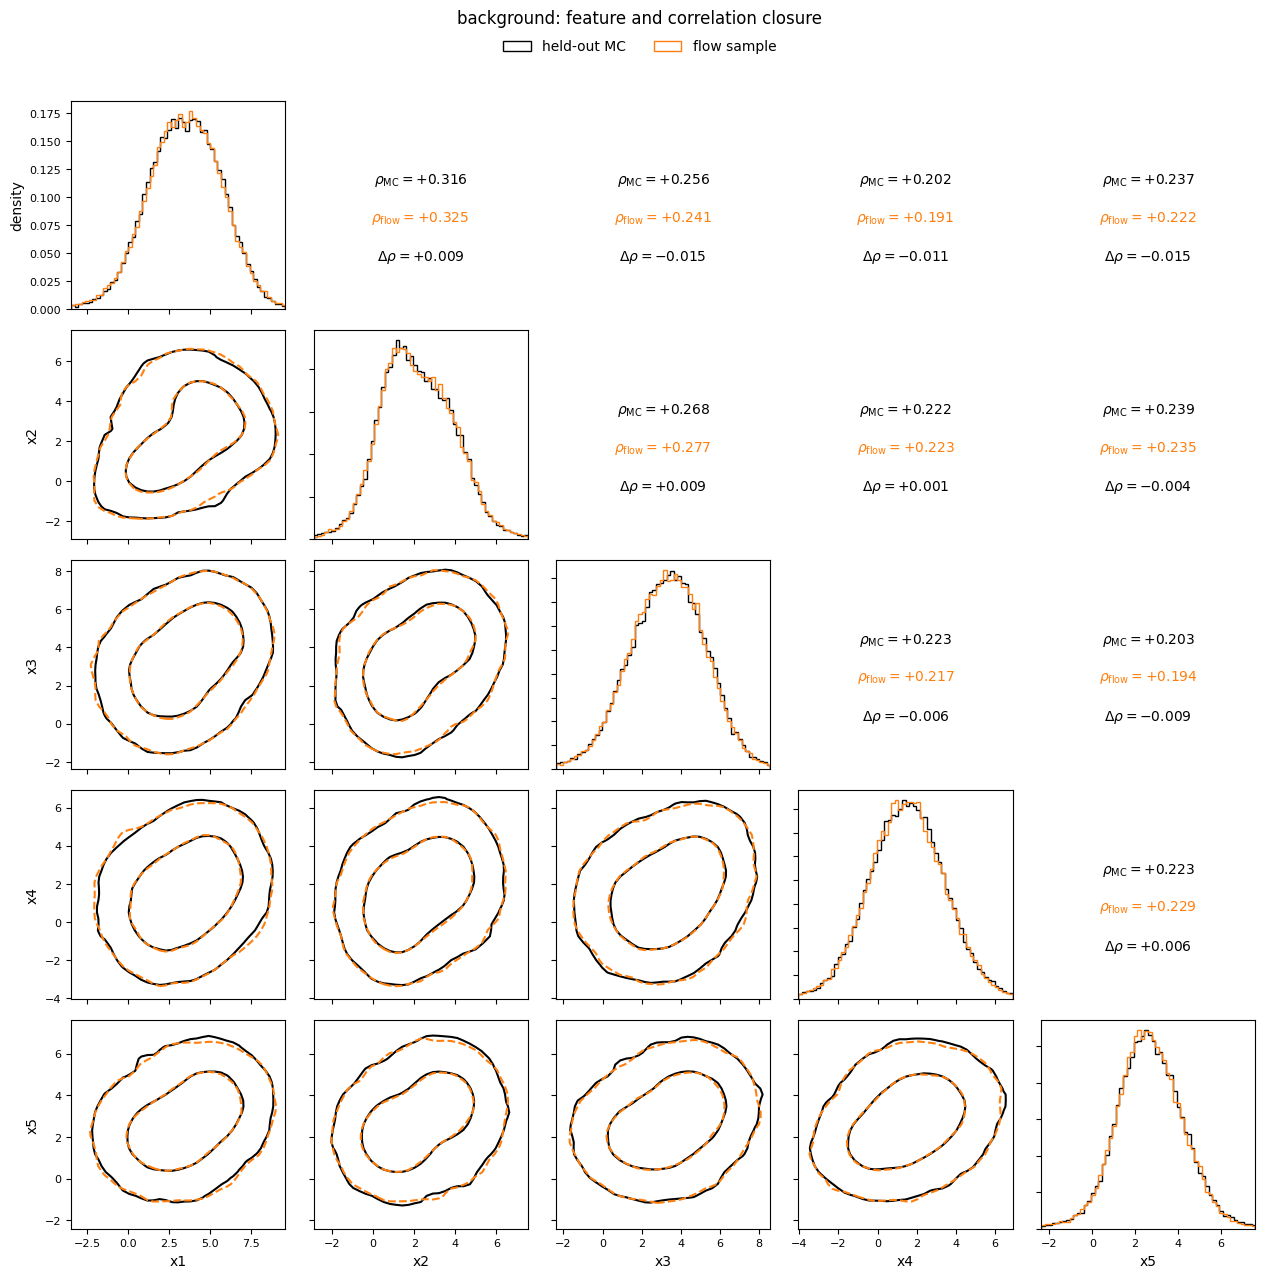

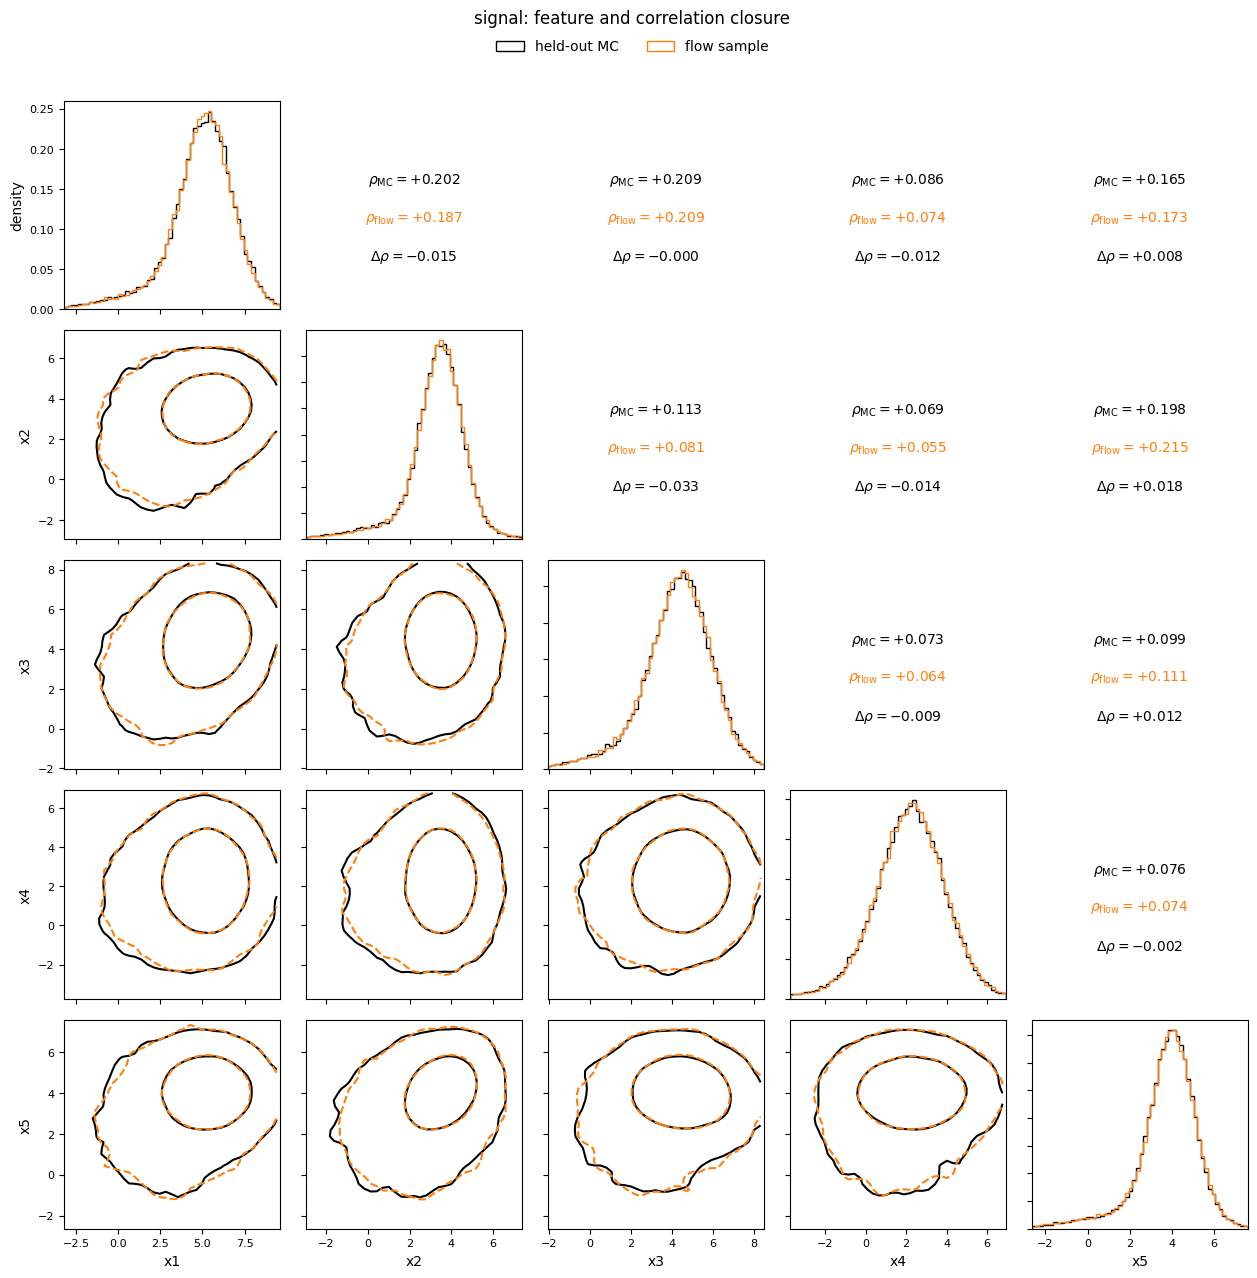

In [7]:
def _highest_density_contour_levels(histogram, probabilities=(0.95, 0.68)):
    """Density thresholds whose enclosed masses approximate probabilities."""
    values = np.asarray(histogram, dtype=float).ravel()
    values = values[np.isfinite(values) & (values > 0.0)]
    if len(values) == 0:
        return np.array([])

    ordered = np.sort(values)[::-1]
    cumulative = np.cumsum(ordered)
    cumulative /= cumulative[-1]
    levels = []
    for probability in probabilities:
        index = min(np.searchsorted(cumulative, probability), len(ordered) - 1)
        levels.append(ordered[index])

    levels = np.unique(np.sort(levels))
    return levels[(levels > 0.0) & (levels < ordered[0])]


def plot_flow_pair_closure(
    sample_name,
    df_eval,
    flow_pack,
    n_plot=50_000,
    n_bins_1d=60,
    n_bins_2d=35,
    contour_smoothing=1.0,
    quantile_range=(0.005, 0.995),
):
    """Pair plot comparing feature marginals and correlations."""
    n_plot = min(int(n_plot), len(df_eval))
    mc = df_eval.sample(n=n_plot, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    generated = flow_sample_x(flow_pack, n_plot)

    q_low, q_high = quantile_range
    if not 0.0 <= q_low < q_high <= 1.0:
        raise ValueError("quantile_range must satisfy 0 <= low < high <= 1.")

    n_features = len(FEATURES)
    limits = []
    for feature_index in range(n_features):
        low = min(
            np.quantile(mc[:, feature_index], q_low),
            np.quantile(generated[:, feature_index], q_low),
        )
        high = max(
            np.quantile(mc[:, feature_index], q_high),
            np.quantile(generated[:, feature_index], q_high),
        )
        limits.append((low, high))

    corr_mc = np.corrcoef(mc, rowvar=False)
    corr_generated = np.corrcoef(generated, rowvar=False)

    fig, axes = plt.subplots(
        n_features,
        n_features,
        figsize=(2.55 * n_features, 2.55 * n_features),
        squeeze=False,
    )

    for row in range(n_features):
        for column in range(n_features):
            ax = axes[row, column]
            x_low, x_high = limits[column]

            if row == column:
                bins = np.linspace(x_low, x_high, n_bins_1d + 1)
                ax.hist(
                    mc[:, column],
                    bins=bins,
                    density=True,
                    histtype="step",
                    color="black",
                    lw=1.8,
                    label="held-out MC",
                )
                ax.hist(
                    generated[:, column],
                    bins=bins,
                    density=True,
                    histtype="step",
                    color="C1",
                    lw=1.8,
                    ls="--",
                    label="flow sample",
                )
                ax.set_xlim(x_low, x_high)
                if row == 0:
                    ax.set_ylabel("density")

            elif row > column:
                y_low, y_high = limits[row]
                x_edges = np.linspace(x_low, x_high, n_bins_2d + 1)
                y_edges = np.linspace(y_low, y_high, n_bins_2d + 1)
                x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
                y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

                hist_mc, _, _ = np.histogram2d(
                    mc[:, column], mc[:, row], bins=(x_edges, y_edges)
                )
                hist_generated, _, _ = np.histogram2d(
                    generated[:, column], generated[:, row], bins=(x_edges, y_edges)
                )
                if contour_smoothing > 0.0:
                    hist_mc = gaussian_filter(hist_mc, sigma=contour_smoothing)
                    hist_generated = gaussian_filter(
                        hist_generated, sigma=contour_smoothing
                    )

                levels_mc = _highest_density_contour_levels(hist_mc)
                levels_generated = _highest_density_contour_levels(hist_generated)
                if len(levels_mc):
                    ax.contour(
                        x_centers,
                        y_centers,
                        hist_mc.T,
                        levels=levels_mc,
                        colors="black",
                        linewidths=1.5,
                    )
                if len(levels_generated):
                    ax.contour(
                        x_centers,
                        y_centers,
                        hist_generated.T,
                        levels=levels_generated,
                        colors="C1",
                        linestyles="--",
                        linewidths=1.5,
                    )
                ax.set_xlim(x_low, x_high)
                ax.set_ylim(y_low, y_high)

            else:
                rho_mc = corr_mc[row, column]
                rho_generated = corr_generated[row, column]
                delta_rho = rho_generated - rho_mc
                ax.set_axis_off()
                ax.text(
                    0.5,
                    0.62,
                    rf"$\rho_{{\rm MC}}={rho_mc:+.3f}$",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=10,
                )
                ax.text(
                    0.5,
                    0.44,
                    rf"$\rho_{{\rm flow}}={rho_generated:+.3f}$",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=10,
                    color="C1",
                )
                ax.text(
                    0.5,
                    0.25,
                    rf"$\Delta\rho={delta_rho:+.3f}$",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=10,
                    fontweight="bold",
                )

            if row >= column:
                ax.tick_params(
                    axis="x",
                    labelbottom=(row == n_features - 1),
                    labelsize=8,
                )
                ax.tick_params(
                    axis="y",
                    labelleft=(column == 0),
                    labelsize=8,
                )
                if row == n_features - 1:
                    ax.set_xlabel(FEATURES[column])
                if column == 0 and row > 0:
                    ax.set_ylabel(FEATURES[row])

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(f"{sample_name}: feature and correlation closure", y=0.999)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.965))
    return fig


fig = plot_flow_pair_closure(
    "background", background_eval, flows["background"]
)
plt.show()

fig = plot_flow_pair_closure(
    "signal", signal_eval, flows["signal"]
)
plt.show()


## Validation 2: closure as a function of the learned log density

The five reconstructed variables can also be compressed to the scalar learned log density

$$
\ell(x) = \log \hat p_\mathrm{flow}(x).
$$

Below, we evaluate the **same trained flow** on two sets of events: held-out MC events and events sampled from the flow. If the learned density reproduces the data distribution, the two distributions of $\ell(x)$ should agree.

The generated reference uses many more events by default than the held-out MC points. Its finite-sampling fluctuations are therefore small, and the visible statistical uncertainty is dominated by the finite MC evaluation sample. The lower panel shows the bin-by-bin ratio $\mathrm{MC}/\mathrm{flow}$; its error bars include the finite counts in both histograms, although the high-statistics flow contribution is small. This does **not** remove uncertainty or bias in the trained flow itself; it only makes the numerical sampling of that fixed flow very precise.

This remains a one-dimensional projection. It is a useful and sensitive diagnostic, but agreement here alone does not prove complete five-dimensional closure because different regions of feature space can have the same value of $\log \hat p(x)$.


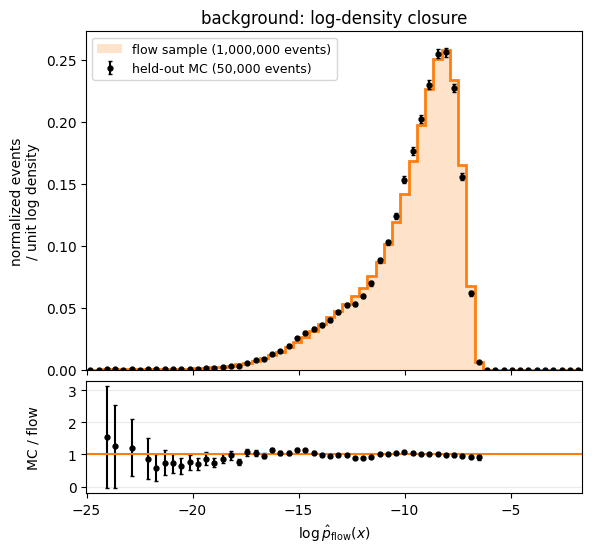

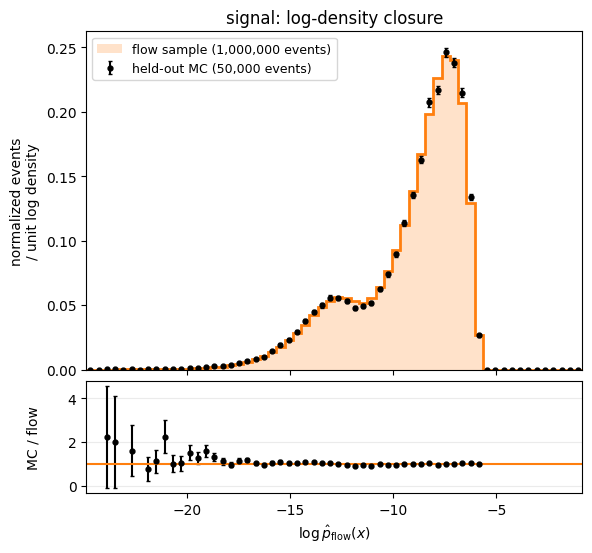

In [9]:
def plot_log_prob_closure(
    sample_name,
    df_eval,
    flow_pack,
    n_mc=50_000,
    n_flow_samples=1_000_000,
    n_bins=60,
    quantile_range=(0.001, 0.999),
):
    """Compare log p_flow(x) for held-out MC and high-statistics flow samples."""

    n_mc = min(int(n_mc), len(df_eval))
    mc = df_eval.sample(n=n_mc, random_state=SEED)[FEATURES]
    log_p_mc = flow_log_prob_x(flow_pack, mc)

    # Use a much larger generated reference so its finite-sampling noise is
    # small compared with the error bars from the held-out MC sample.
    generated = flow_sample_x(flow_pack, int(n_flow_samples))
    log_p_generated = flow_log_prob_x(flow_pack, generated)
    del generated

    log_p_mc = log_p_mc[np.isfinite(log_p_mc)]
    log_p_generated = log_p_generated[np.isfinite(log_p_generated)]
    if len(log_p_mc) == 0 or len(log_p_generated) == 0:
        raise ValueError("The flow returned no finite log-probability values.")

    q_low, q_high = quantile_range
    if not 0.0 <= q_low < q_high <= 1.0:
        raise ValueError("quantile_range must satisfy 0 <= low < high <= 1.")

    # Use robust limits from both distributions so a few extreme tail events
    # do not make the central closure comparison unreadable.
    x_min = min(
        np.quantile(log_p_mc, q_low),
        np.quantile(log_p_generated, q_low),
    )
    x_max = max(
        np.quantile(log_p_mc, q_high),
        np.quantile(log_p_generated, q_high),
    )
    x_min = x_min - 5
    x_max = x_max + 5

    edges = np.linspace(x_min, x_max, n_bins + 1)
    widths = np.diff(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    mc_counts, _ = np.histogram(log_p_mc, bins=edges)
    generated_counts, _ = np.histogram(log_p_generated, bins=edges)

    # Normalize over the displayed range.
    mc_norm = mc_counts.sum()
    generated_norm = generated_counts.sum()
    mc_density = mc_counts / (mc_norm * widths)
    mc_error = np.sqrt(mc_counts) / (mc_norm * widths)
    generated_density = generated_counts / (generated_norm * widths)

    fig, (ax, ratio_ax) = plt.subplots(
        2,
        1,
        figsize=(6.4, 6.0),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )
    ax.stairs(
        generated_density,
        edges,
        color="C1",
        lw=2,
        fill=True,
        alpha=0.22,
        label=f"flow sample ({len(log_p_generated):,} events)",
    )
    ax.stairs(generated_density, edges, color="C1", lw=2)
    ax.errorbar(
        centers,
        mc_density,
        yerr=mc_error,
        fmt="o",
        ms=3.5,
        color="black",
        capsize=1.5,
        label=f"held-out MC ({len(log_p_mc):,} events)",
    )
    ax.set_ylabel("normalized events\n/ unit log density")
    ax.set_title(f"{sample_name}: log-density closure")
    ax.legend(fontsize=9)

    # The ratio uncertainty includes finite counts from both histograms. The
    # generated-reference term is normally much smaller because it has many
    # more events. Flow-training uncertainty is not included.
    valid = (mc_counts > 0) & (generated_counts > 0)
    ratio = mc_density[valid] / generated_density[valid]
    ratio_error = ratio * np.sqrt(
        1.0 / mc_counts[valid] + 1.0 / generated_counts[valid]
    )
    ratio_ax.errorbar(
        centers[valid],
        ratio,
        yerr=ratio_error,
        fmt="o",
        ms=3.5,
        color="black",
        capsize=1.5,
    )
    ratio_ax.axhline(1.0, color="C1", lw=1.5)
    ratio_ax.set_xlabel(r"$\log \hat p_{\rm flow}(x)$")
    ratio_ax.set_ylabel("MC / flow")
    ratio_ax.set_xlim(edges[0], edges[-1])
    ratio_ax.grid(axis="y", alpha=0.25)

    fig.align_ylabels((ax, ratio_ax))
    fig.subplots_adjust(hspace=0.05)
    return fig


fig = plot_log_prob_closure(
    "background", background_eval, flows["background"]
)
plt.show()

fig = plot_log_prob_closure(
    "signal", signal_eval, flows["signal"]
)
plt.show()


## Validation 3: compare with the analytic smeared truth

For the generator, the truth-level variables are Gaussian mixtures in $y$.  The reco variables are generated as

$$
x = D y + \epsilon, \qquad \epsilon_i \sim \mathcal{N}(0, \sigma_{\mathrm{res},i}^2),
$$

where $D = \mathrm{diag}(\mathrm{scale})$.  Therefore each Gaussian component remains Gaussian after smearing:

$$
\mu_x = D\mu_y, \qquad \Sigma_x = D\Sigma_yD^T + \mathrm{diag}(\sigma_\mathrm{res}^2).
$$

This analytic truth is only available because the tutorial toy model is simple.  It is useful here as a clean closure check of the flow density itself.

In [10]:
def reco_components_from_truth_components(components):
    scale, resolution = smearing_parameters()
    scale = np.asarray(scale, dtype=float)
    resolution = np.asarray(resolution, dtype=float)
    D = np.diag(scale)
    response_cov = np.diag(resolution ** 2)

    reco_components = []
    for frac, mean_y, cov_y in components:
        mean_x = scale * np.asarray(mean_y, dtype=float)
        cov_x = D @ np.asarray(cov_y, dtype=float) @ D.T + response_cov
        reco_components.append((frac, mean_x, cov_x))
    return reco_components


def mixture_log_density(x, components):
    x = np.asarray(x, dtype=float)
    fracs = np.asarray([c[0] for c in components], dtype=float)
    fracs = fracs / fracs.sum()

    terms = []
    for f, (_, mean, cov) in zip(fracs, components):
        terms.append(
            np.log(f) + multivariate_normal(mean=mean, cov=cov, allow_singular=False).logpdf(x)
        )
    return logsumexp(np.vstack(terms), axis=0)


TRUTH_RECO_COMPONENTS = {
    "background": reco_components_from_truth_components(background_components()),
    "signal": reco_components_from_truth_components(signal_components()),
}

background: corr(log p) = 0.9978, RMSE = 0.1530, bias = -0.0119


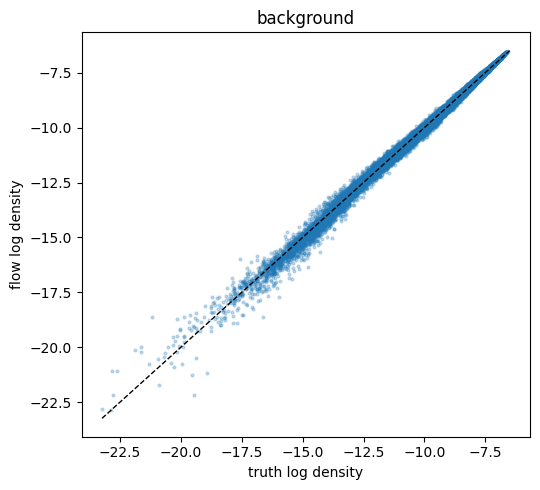

signal: corr(log p) = 0.9991, RMSE = 0.1123, bias = -0.0050


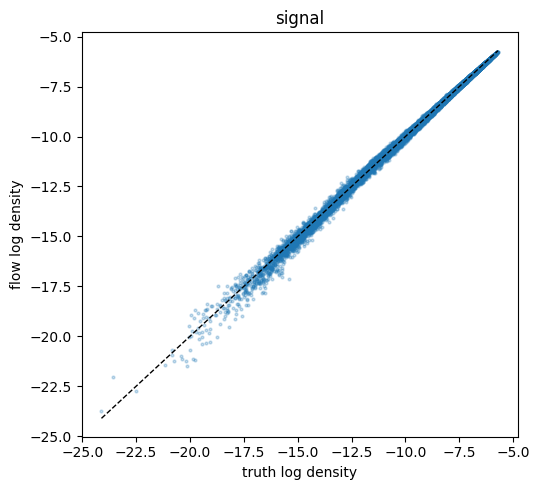

In [11]:
def compare_log_density_to_truth(sample_name, df_eval, flow_pack, n_points=25_000):
    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    log_p_flow = flow_log_prob_x(flow_pack, x)
    log_p_truth = mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
    delta = log_p_flow - log_p_truth

    corr = np.corrcoef(log_p_truth, log_p_flow)[0, 1]
    rmse = np.sqrt(np.mean(delta ** 2))
    bias = np.mean(delta)
    print(f"{sample_name}: corr(log p) = {corr:.4f}, RMSE = {rmse:.4f}, bias = {bias:.4f}")

    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    ax.scatter(log_p_truth, log_p_flow, s=4, alpha=0.25)
    lo = min(log_p_truth.min(), log_p_flow.min())
    hi = max(log_p_truth.max(), log_p_flow.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("truth log density")
    ax.set_ylabel("flow log density")
    ax.set_title(sample_name)
    fig.tight_layout()
    return fig

fig = compare_log_density_to_truth("background", background_eval, flows["background"])
plt.show()

fig = compare_log_density_to_truth("signal", signal_eval, flows["signal"])
plt.show()

In [12]:
def compare_log_density_to_truth_binned(
    sample_name,
    df_eval,
    flow_pack,
    n_points=100_000,
    n_bins=25,
    binning="quantile",
    show_scatter=False,
):
    """Binned calibration curve for log p_flow against log p_truth."""

    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)

    log_p_flow = flow_log_prob_x(flow_pack, x)
    log_p_truth = mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
    delta = log_p_flow - log_p_truth

    if binning == "quantile":
        # Roughly equal statistics per bin.
        edges = np.quantile(log_p_truth, np.linspace(0.0, 1.0, n_bins + 1))
        edges = np.unique(edges)
    elif binning == "uniform":
        edges = np.linspace(log_p_truth.min(), log_p_truth.max(), n_bins + 1)
    else:
        edges = np.asarray(binning, dtype=float)

    if len(edges) < 3:
        raise ValueError("Need at least two non-empty bins for the calibration plot.")

    eps = 1.0e-9 * max(1.0, float(edges[-1] - edges[0]))
    edges = edges.astype(float).copy()
    edges[0] -= eps
    edges[-1] += eps

    bin_index = np.searchsorted(edges, log_p_truth, side="right") - 1
    bin_index = np.clip(bin_index, 0, len(edges) - 2)

    rows = []
    for i in range(len(edges) - 1):
        mask = bin_index == i
        count = int(mask.sum())

        if count == 0:
            rows.append(
                {
                    "bin": i,
                    "truth_lo": edges[i],
                    "truth_hi": edges[i + 1],
                    "count": count,
                    "truth_mean": np.nan,
                    "flow_mean": np.nan,
                    "flow_sem": np.nan,
                    "delta_mean": np.nan,
                    "delta_sem": np.nan,
                }
            )
            continue

        flow_std = log_p_flow[mask].std(ddof=1) if count > 1 else 0.0
        delta_std = delta[mask].std(ddof=1) if count > 1 else 0.0

        rows.append(
            {
                "bin": i,
                "truth_lo": edges[i],
                "truth_hi": edges[i + 1],
                "count": count,
                "truth_mean": log_p_truth[mask].mean(),
                "flow_mean": log_p_flow[mask].mean(),
                "flow_sem": flow_std / np.sqrt(count),
                "delta_mean": delta[mask].mean(),
                "delta_sem": delta_std / np.sqrt(count),
            }
        )

    calib = pd.DataFrame(rows)
    valid = calib["count"] > 0

    binned_bias = np.average(
        calib.loc[valid, "delta_mean"],
        weights=calib.loc[valid, "count"],
    )
    binned_rms = np.sqrt(
        np.average(
            calib.loc[valid, "delta_mean"] ** 2,
            weights=calib.loc[valid, "count"],
        )
    )
    max_abs_bias = np.nanmax(np.abs(calib.loc[valid, "delta_mean"]))

    print(
        f"{sample_name}: binned bias = {binned_bias:.4f}, "
        f"binned RMS bias = {binned_rms:.4f}, "
        f"max |bin bias| = {max_abs_bias:.4f}"
    )

    fig, (ax, rax) = plt.subplots(
        2,
        1,
        figsize=(6.4, 6.0),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    if show_scatter:
        ax.scatter(log_p_truth, log_p_flow, s=3, alpha=0.10)

    flow_step = calib["flow_mean"].to_numpy()
    delta_step = calib["delta_mean"].to_numpy()

    ax.step(
        edges,
        np.r_[flow_step, flow_step[-1]],
        where="post",
        lw=2,
        label="bin mean",
    )
    ax.errorbar(
        calib.loc[valid, "truth_mean"],
        calib.loc[valid, "flow_mean"],
        yerr=calib.loc[valid, "flow_sem"],
        fmt="o",
        ms=3,
        capsize=2,
    )

    lo = min(edges[0], np.nanmin(flow_step))
    hi = max(edges[-1], np.nanmax(flow_step))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect calibration")
    ax.set_ylabel(r"$\langle \log \hat p_{\rm flow} \rangle$")
    ax.set_title(f"{sample_name}: binned log-density calibration")
    ax.legend(fontsize=8)

    rax.step(
        edges,
        np.r_[delta_step, delta_step[-1]],
        where="post",
        lw=2,
    )
    rax.errorbar(
        calib.loc[valid, "truth_mean"],
        calib.loc[valid, "delta_mean"],
        yerr=calib.loc[valid, "delta_sem"],
        fmt="o",
        ms=3,
        capsize=2,
    )
    rax.axhline(0.0, color="k", lw=1)
    rax.set_xlabel(r"truth $\log p(x)$ bin")
    rax.set_ylabel(r"$\langle \Delta \log p \rangle$")
    rax.set_xlim(edges[0], edges[-1])

    return fig, calib

background: binned bias = -0.0110, binned RMS bias = 0.0420, max |bin bias| = 0.0931


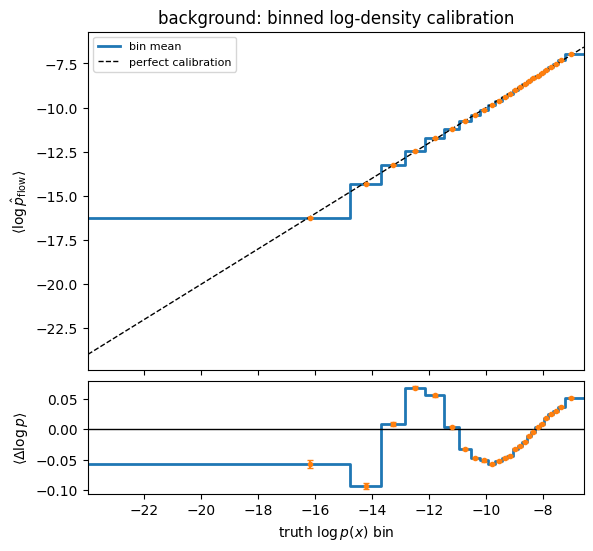

signal: binned bias = -0.0055, binned RMS bias = 0.0337, max |bin bias| = 0.1091


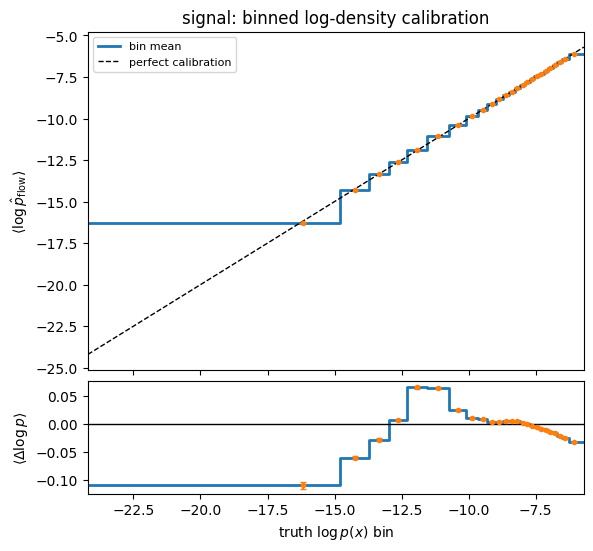

In [13]:
fig, background_logp_calibration = compare_log_density_to_truth_binned(
    "background", background_eval, flows["background"]
)
plt.show()

fig, signal_logp_calibration = compare_log_density_to_truth_binned(
    "signal", signal_eval, flows["signal"]
)
plt.show()

## Direct likelihood from the learned densities

Because the flows estimate $p_\mathrm{sig}(x)$ and $p_\mathrm{bkg}(x)$ directly, we do **not** need to choose a reference density and we do **not** need to calculate ratios.

For a direct extended unbinned likelihood, define the event probability

$$
p(x \mid \mu) = \frac{1}{\mu\,\lambda_\mathrm{sig}+ \lambda_\mathrm{bkg} }\left( \mu\,\lambda_\mathrm{sig}\,\hat p_\mathrm{sig}(x)
+ \lambda_\mathrm{bkg}\,\hat p_\mathrm{bkg}(x)\right).
$$

Dropping constants independent of $\mu$,

$$
-2\log L(\mu)
= -2 \sum_i w_i \log p(x_i\mid\mu)
- 2\log \mathrm{Poisson}(N_\mathrm{data};\mu\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}).
$$

The code below stores `p_sig` and `p_bkg` as the yield-weighted terms
$\lambda_\mathrm{sig}\hat p_\mathrm{sig}(x_i)$ and
$\lambda_\mathrm{bkg}\hat p_\mathrm{bkg}(x_i)$, so the core likelihood line is just

```python
prob = mu * p_sig + p_bkg
```


In [14]:
asimov_dataset = pd.concat([background_eval, signal_eval], ignore_index=True).astype("float32").copy()
weights_asimov = np.asarray(asimov_dataset["weight"], dtype=np.float64)
X_asimov = asimov_dataset[FEATURES].to_numpy(dtype=np.float32)

lam_sig = float(TOTAL_YIELD["signal"])
lam_bkg = float(TOTAL_YIELD["background"])

log_p_sig_flow = flow_log_prob_x(flows["signal"], X_asimov)
log_p_bkg_flow = flow_log_prob_x(flows["background"], X_asimov)

In [17]:
# Flow-based intensities
p_sig_flow_np = lam_sig * np.exp(np.clip(log_p_sig_flow, -745.0, 50.0))
p_bkg_flow_np = lam_bkg * np.exp(np.clip(log_p_bkg_flow, -745.0, 50.0))

# Truth-based intensities
log_p_sig_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["signal"])
log_p_bkg_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["background"])

p_sig_truth_np = lam_sig * np.exp(np.clip(log_p_sig_truth, -745.0, 50.0))
p_bkg_truth_np = lam_bkg * np.exp(np.clip(log_p_bkg_truth, -745.0, 50.0))

## Fit $\mu$ with a manual JAX likelihood


This is intentionally small: the normalizing flows provide the event densities, and JAX provides the gradient of the likelihood.

In [ ]:
p_sig = jnp.asarray(p_sig_flow_np, dtype=jnp.float64)
p_bkg = jnp.asarray(p_bkg_flow_np, dtype=jnp.float64)
weights = jnp.asarray(weights_asimov, dtype=jnp.float64)
EPS = 1.0e-300


def nll_manual(params):
    mu = params[0]
    prob = mu * p_sig + p_bkg
    n_expected = mu * lam_sig + lam_bkg

    # The maximum protects the log.  The final where() enforces the physical
    # region and keeps the optimizer away from invalid negative intensities.
    nll = -2.0 * jnp.sum(weights * jnp.log(jnp.maximum(prob, EPS))) + 2.0 * n_expected
    invalid = (mu < 0.0) | (n_expected <= 0.0) | jnp.any(prob <= 0.0)
    return jnp.where(invalid, 1.0e30, nll)

inf_manual = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_manual),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_manual)),  # analytic gradient, for free
)

print("\n" + "=" * 40)
print(" DIRECT FLOW-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_manual.perform_fit(freeze_params=[])
mu_min = inf_manual.pulls_global_fit


 DIRECT FLOW-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -5.994e+06                 │         Nfcn = 21, Ngrad = 2         │
│ EDM = 9.61e-06 (Goal: 0.0002)    │            time = 2.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬─────────

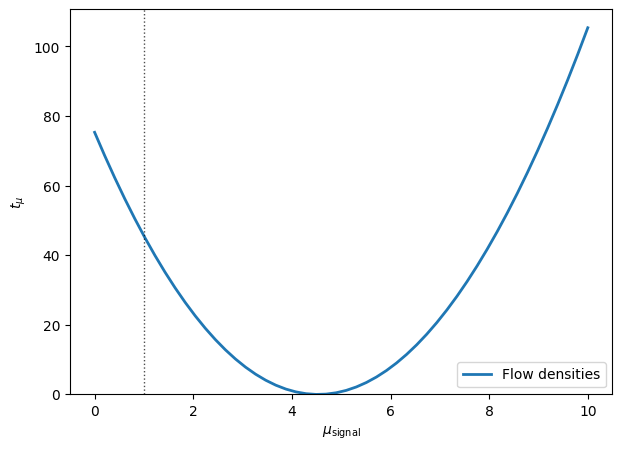

In [ ]:
SCAN_RANGE = (0.0, 10.0)
scan_flow, tmu_flow = inf_manual.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_flow, tmu_flow, lw=2, label="Flow densities")
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_\mathrm{signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
plt.show()



 ANALYTIC RECO-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -6.013e+06                 │         Nfcn = 24, Ngrad = 1         │
│ EDM = 1.23e-10 (Goal: 0.0002)    │            time = 1.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

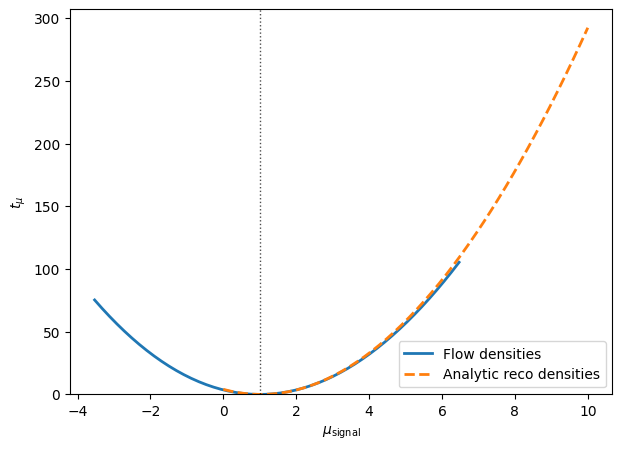

In [ ]:
def make_direct_density_nll(p_sig_np, p_bkg_np, weights_np, lam_sig_value, lam_bkg_value):
    p_sig_j = jnp.asarray(p_sig_np, dtype=jnp.float64)
    p_bkg_j = jnp.asarray(p_bkg_np, dtype=jnp.float64)
    weights_j = jnp.asarray(weights_np, dtype=jnp.float64)
    lam_sig_value = float(lam_sig_value)
    lam_bkg_value = float(lam_bkg_value)

    def _nll(params):
        mu = params[0]
        prob = mu * p_sig_j + p_bkg_j
        n_expected = mu * lam_sig_value + lam_bkg_value
        nll = -2.0 * jnp.sum(weights_j * jnp.log(jnp.maximum(prob, EPS))) + 2.0 * n_expected
        invalid = (mu < 0.0) | (n_expected <= 0.0) | jnp.any(prob <= 0.0)
        return jnp.where(invalid, 1.0e30 + 1.0e12 * (mu - 1.0) ** 2, nll)

    return _nll


log_p_sig_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["signal"])
log_p_bkg_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["background"])

p_sig_truth_np = lam_sig * np.exp(np.clip(log_p_sig_truth, -745.0, 50.0))
p_bkg_truth_np = lam_bkg * np.exp(np.clip(log_p_bkg_truth, -745.0, 50.0))

nll_truth = make_direct_density_nll(
    p_sig_truth_np,
    p_bkg_truth_np,
    weights_asimov,
    lam_sig,
    lam_bkg,
)

inf_truth = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_truth),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_truth)),
)

print("\n" + "=" * 40)
print(" ANALYTIC RECO-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_truth.perform_fit(freeze_params=[])

scan_truth, tmu_truth = inf_truth.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_flow-mu_min+1., tmu_flow, lw=2, label="Flow densities")
ax.plot(scan_truth, tmu_truth, lw=2, ls="--", label="Analytic reco densities")
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_\mathrm{signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
plt.show()


## Suggested exercises

1. Remove the extended-rate term from `nll_manual` and compare the behavior of the fit with the full extended likelihood.
2. Toggle `USE_QUADRATIC_SPLINE`, retrain the two flows, and compare the validation plots with the RealNVP result.
3. Vary the number of coupling layers, hidden-layer width, and spline bins to study the trade-off between expressivity and training time.
4. Train on truth-level `y*` variables instead of reco-level `x*` variables and compare how detector smearing changes the achievable sensitivity.
